In [ ]:
# 1) Setup, target construction, and robust column detection

In [3]:
# --- Setup: load BTC hourly data, detect time & close columns, build 1h-ahead target ---
import math, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from typing import Optional, Dict, Tuple, List

# Adjust if your file lives elsewhere
DATA_PATH = "data/btc1h_usdt.csv"

raw = pd.read_csv(DATA_PATH)

def detect_time_col(df: pd.DataFrame) -> Optional[str]:
    candidates = ["timestamp","time","date","datetime","open_time","close_time","open time","close time"]
    for c in [c for c in df.columns if c.lower() in candidates] + list(df.columns):
        try:
            ts = pd.to_datetime(df[c], utc=True, errors="raise")
            if ts.is_monotonic_increasing or ts.is_monotonic_decreasing:
                return c
        except: 
            pass
    return None

def detect_close_col(df: pd.DataFrame) -> Optional[str]:
    keys = ["close","price","last","close_usdt","closeprice","closing"]
    for key in keys:
        for c in df.columns:
            if key in c.lower():
                return c
    nums = df.select_dtypes(include=[np.number]).columns.tolist()
    if nums:
        return max(nums, key=lambda c: df[c].var(skipna=True))
    return None

time_col = detect_time_col(raw)
close_col = detect_close_col(raw)
assert time_col and close_col, f"Could not detect time/close automatically. Columns: {list(raw.columns)[:30]}"

df = raw.copy()
df[time_col] = pd.to_datetime(df[time_col], utc=True, errors="coerce")
df = df.dropna(subset=[time_col]).sort_values(time_col).reset_index(drop=True)
df[close_col] = pd.to_numeric(df[close_col], errors="coerce")
df = df.dropna(subset=[close_col]).reset_index(drop=True)

# Log returns & next-hour target
df["log_price"] = np.log(df[close_col])
df["ret_1h"]     = df["log_price"].diff()
df["y_next_ret"] = df["ret_1h"].shift(-1)

# Basic leakage-safe features: return lags + 24h volatility
MAX_LAG = 24
for lag in range(1, MAX_LAG + 1):
    df[f"ret_lag_{lag}"] = df["ret_1h"].shift(lag)
df["vol_24h"] = df["ret_1h"].rolling(24, min_periods=24).std()

# Clean warm-up
df = df.dropna(subset=[f"ret_lag_{MAX_LAG}", "vol_24h", "y_next_ret"]).reset_index(drop=True)


In [ ]:
# 2) Train/test split + Baselines vs ML (OLS, RF, HGB)

In [8]:
# --- Split: Train <= 2023; Test = 2024 (fallback to last 20% if 2024 not present) ---
t = pd.to_datetime(df[time_col], utc=True)
has_2024 = (t.dt.year == 2024).any()
has_train = (t.dt.year <= 2023).any()

if has_2024 and has_train:
    train_mask = t.dt.year <= 2023
    test_mask  = t.dt.year == 2024
else:
    cut = int(len(df)*0.8)
    train_mask = pd.Series([True]*cut + [False]*(len(df)-cut), index=df.index)
    test_mask  = ~train_mask

feat_cols = [c for c in df.columns if c.startswith("ret_lag_")] + ["vol_24h"]
X_train, y_train = df.loc[train_mask, feat_cols], df.loc[train_mask, "y_next_ret"]
X_test,  y_test  = df.loc[test_mask,  feat_cols], df.loc[test_mask,  "y_next_ret"]
t_test = t.loc[test_mask]

# --- Models ---
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
# Backward-compatible RMSE helper (works with any sklearn version)
def _rmse(y_true, y_pred):
    try:
        # Newer sklearn (>= ~0.22)
        return mean_squared_error(y_true, y_pred, squared=False)
    except TypeError:
        # Older sklearn: no 'squared' kw — compute sqrt(MSE) manually
        return np.sqrt(mean_squared_error(y_true, y_pred))
        
def metrics(y_true, y_pred) -> dict:
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = _rmse(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    da   = (np.sign(y_true) == np.sign(y_pred)).mean()
    return {"MAE": mae, "RMSE": rmse, "R2": r2, "DA": da}

# Naïve baseline (predict last observed return)
def naive_last_return(y_true_like: pd.Series, y_hist: pd.Series) -> np.ndarray:
    preds = []
    last_hist = y_hist.iloc[-1]
    for i in range(len(y_true_like)):
        preds.append(last_hist if i == 0 else y_true_like.iloc[i-1])
    return np.array(preds)

y_pred_naive = naive_last_return(y_test.reset_index(drop=True), y_train.reset_index(drop=True))

pipe_ols = Pipeline([("scaler", StandardScaler()), ("ols", LinearRegression())])
pipe_ols.fit(X_train, y_train)
y_pred_ols = pipe_ols.predict(X_test)

rf  = RandomForestRegressor(n_estimators=150, n_jobs=-1, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

hgb = HistGradientBoostingRegressor(max_iter=200, learning_rate=0.06, random_state=42)
hgb.fit(X_train, y_train)
y_pred_hgb = hgb.predict(X_test)

results = pd.DataFrame([
    {"Model": "Naive (Last Return)", **metrics(y_test, y_pred_naive)},
    {"Model": "OLS (Linear Regression)", **metrics(y_test, y_pred_ols)},
    {"Model": "RandomForest", **metrics(y_test, y_pred_rf)},
    {"Model": "HistGradientBoosting", **metrics(y_test, y_pred_hgb)},
]).sort_values("MAE").reset_index(drop=True)

results


,Model,MAE,RMSE,R2,DA
0,HistGradientBoosting,0.003667,0.005583,0.000830,0.506261
1,OLS (Linear Regression),0.003677,0.005594,-0.003122,0.505920
2,RandomForest,0.003724,0.005630,-0.016022,0.491917
3,Naive (Last Return),0.005443,0.007927,-1.014449,0.466758


In [9]:
# 3) Publication-ready simple plots (one plot per figure, no styles)

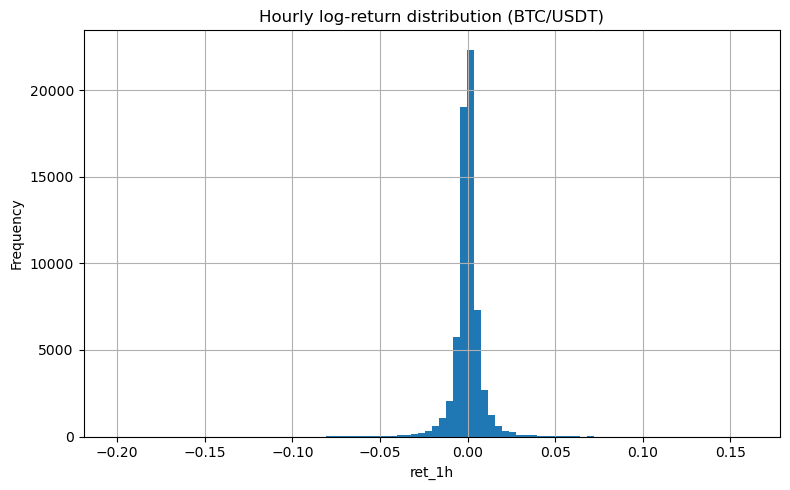

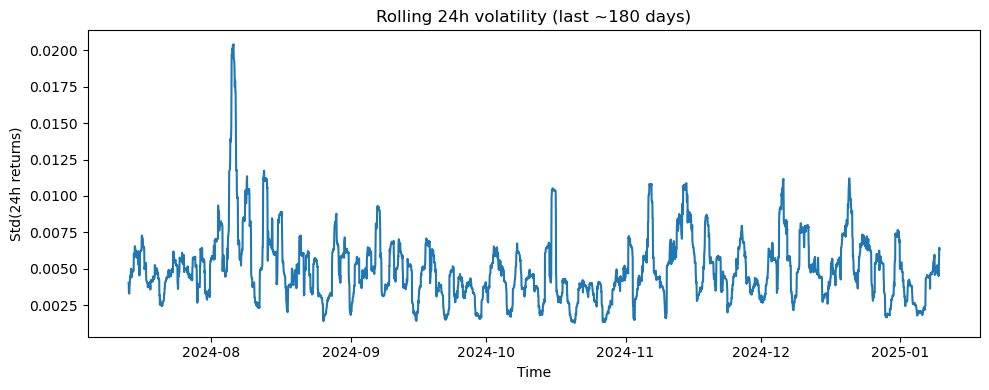

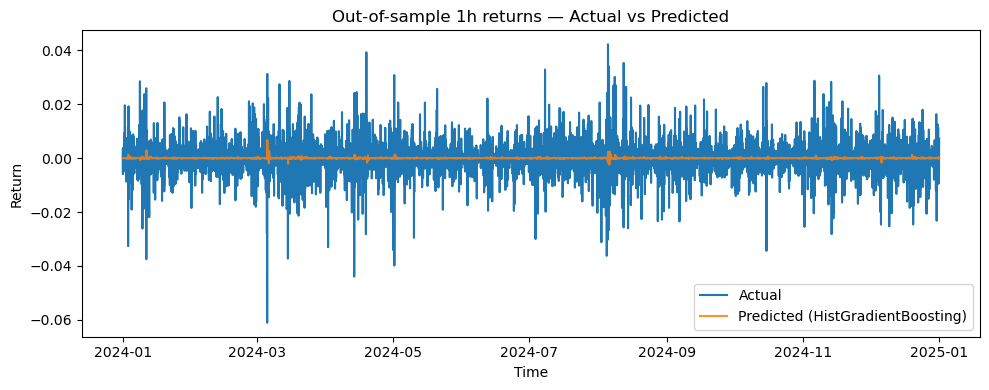

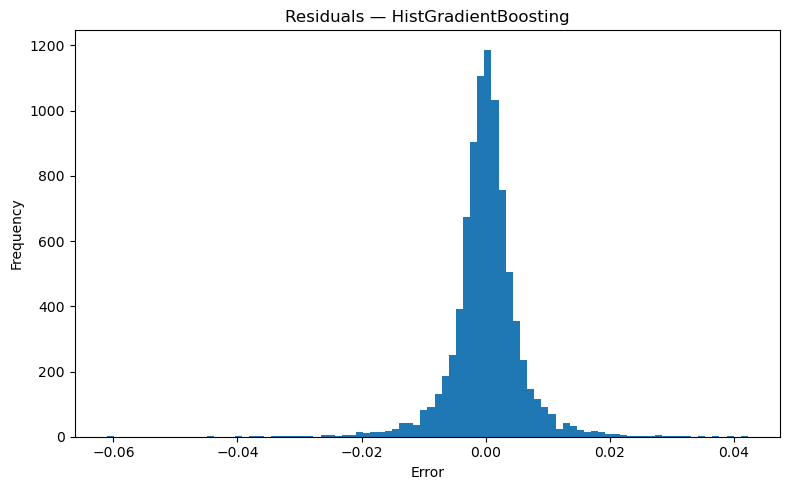

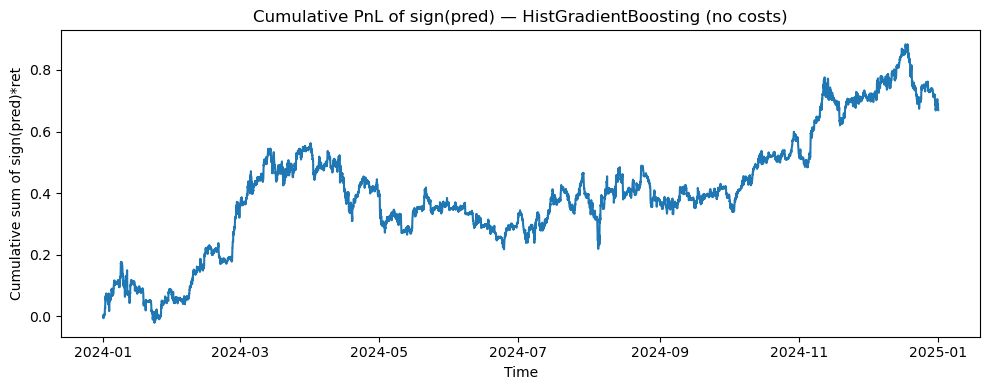

In [10]:
# Figure R-1 — Return histogram
plt.figure(figsize=(8,5))
df["ret_1h"].hist(bins=90)
plt.title("Hourly log-return distribution (BTC/USDT)")
plt.xlabel("ret_1h"); plt.ylabel("Frequency")
plt.tight_layout(); plt.show()

# Figure R-2 — Rolling 24h volatility over the last ~180 days
plt.figure(figsize=(10,4))
tail_n = min(len(df), 180*24)
plt.plot(t.iloc[-tail_n:], df["vol_24h"].iloc[-tail_n:])
plt.title("Rolling 24h volatility (last ~180 days)")
plt.xlabel("Time"); plt.ylabel("Std(24h returns)")
plt.tight_layout(); plt.show()

# Choose best model by MAE for plots
best = results.iloc[0]["Model"]
pred_map = {"Naive (Last Return)": y_pred_naive,
            "OLS (Linear Regression)": y_pred_ols,
            "RandomForest": y_pred_rf,
            "HistGradientBoosting": y_pred_hgb}
y_pred_best = pred_map[best]

# Figure R-3 — Out-of-sample Actual vs Predicted
plt.figure(figsize=(10,4))
plt.plot(t_test, y_test.values, label="Actual")
plt.plot(t_test, y_pred_best, label=f"Predicted ({best})", alpha=0.85)
plt.title("Out-of-sample 1h returns — Actual vs Predicted")
plt.xlabel("Time"); plt.ylabel("Return"); plt.legend()
plt.tight_layout(); plt.show()

# Figure R-4 — Residuals histogram (best model)
resid = y_test.values - y_pred_best
plt.figure(figsize=(8,5))
plt.hist(resid, bins=90)
plt.title(f"Residuals — {best}")
plt.xlabel("Error"); plt.ylabel("Frequency")
plt.tight_layout(); plt.show()

# Figure R-5 — Simple cumulative PnL (unit exposure, no costs)
position = np.sign(y_pred_best)
pnl = position * y_test.values
cum_pnl = np.cumsum(pnl)

plt.figure(figsize=(10,4))
plt.plot(t_test, cum_pnl)
plt.title(f"Cumulative PnL of sign(pred) — {best} (no costs)")
plt.xlabel("Time"); plt.ylabel("Cumulative sum of sign(pred)*ret")
plt.tight_layout(); plt.show()


In [11]:
# 4) Feature importance (permutation)

,feature,importance_mean,importance_std
0,ret_lag_20,0.000107,0.000144
1,ret_lag_15,0.000062,0.000101
2,ret_lag_3,0.000062,0.000132
3,ret_lag_4,0.000062,0.000244
4,ret_lag_17,0.000045,0.000097
5,ret_lag_6,0.000036,0.000133
6,ret_lag_12,0.000027,0.000093
7,vol_24h,0.000000,0.000000
8,ret_lag_18,0.000000,0.000000
9,ret_lag_16,0.000000,0.000000


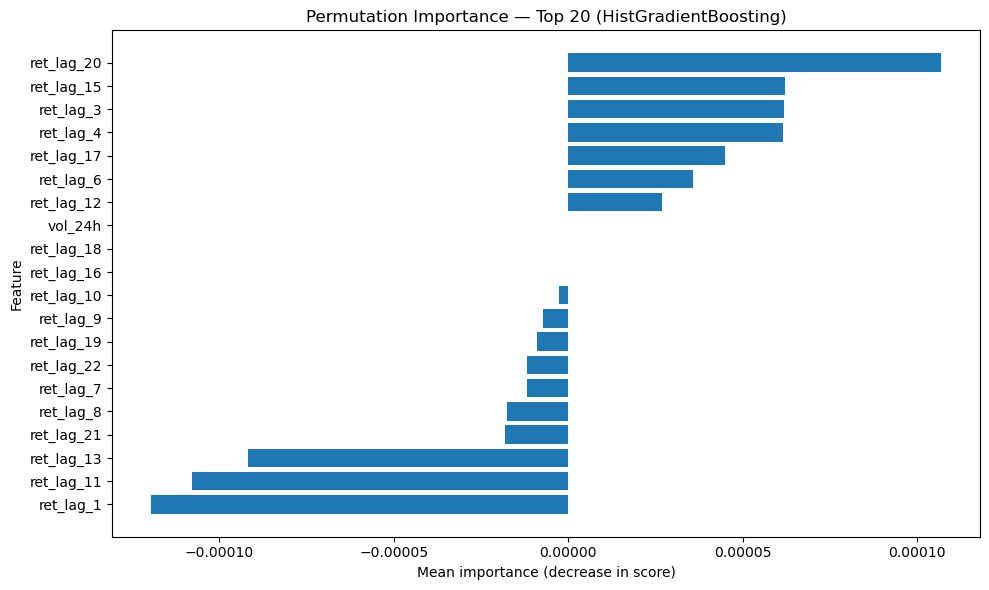

In [12]:
# Permutation importance (top features). Works with OLS (pipeline), RF, HGB
from sklearn.inspection import permutation_importance

est_map = {"OLS (Linear Regression)": pipe_ols, "RandomForest": rf, "HistGradientBoosting": hgb}
if best in est_map:
    est = est_map[best]
    # Use a modest sample for speed, keep it leakage-safe (only test window)
    sample_n = min(len(X_test), 2000)
    Xs, ys = X_test.tail(sample_n), y_test.tail(sample_n)
    r = permutation_importance(est, Xs, ys, n_repeats=7, random_state=42, n_jobs=-1)
    imp = (pd.DataFrame({"feature": Xs.columns,
                         "importance_mean": r.importances_mean,
                         "importance_std":  r.importances_std})
             .sort_values("importance_mean", ascending=False)
             .reset_index(drop=True))
    display(imp.head(25))

    # Figure R-6 — Top-20 permutation importance
    top = imp.head(20)
    plt.figure(figsize=(10,6))
    plt.barh(top["feature"][::-1], top["importance_mean"][::-1])
    plt.title(f"Permutation Importance — Top 20 ({best})")
    plt.xlabel("Mean importance (decrease in score)"); plt.ylabel("Feature")
    plt.tight_layout(); plt.show()


In [13]:
# 5) Mini stats pack (DM test + DA binomial test)

In [14]:
# --- Diebold–Mariano test for two forecast series (squared-error loss) ---
# Use on y_test, y_pred_modelA, y_pred_modelB
import numpy as np

def dm_test(y_true: np.ndarray, y_pred_a: np.ndarray, y_pred_b: np.ndarray, h: int = 1) -> Tuple[float, float]:
    """
    Return (DM_stat, p_value) for equal predictive accuracy (two-sided).
    Uses squared-error loss and Newey-West variance with lag = h-1.
    """
    e_a = y_true - y_pred_a
    e_b = y_true - y_pred_b
    d_t = (e_a**2) - (e_b**2)              # loss differential
    d_bar = np.mean(d_t)
    T = len(d_t)

    # Newey-West variance estimate
    def newey_west_var(x, lag):
        x = x - x.mean()
        gamma0 = np.mean(x*x)
        var = gamma0
        for l in range(1, lag+1):
            w = 1 - l/(lag+1)
            gamma = np.mean(x[l:]*x[:-l])
            var += 2 * w * gamma
        return var

    lag = max(h-1, 0)
    s2 = newey_west_var(d_t, lag) / T
    dm = d_bar / np.sqrt(s2 + 1e-12)
    # two-sided p-value under N(0,1)
    from math import erf, sqrt
    p = 2*(1 - 0.5*(1+erf(abs(dm)/sqrt(2))))
    return dm, p

# Example: compare HGB vs RF on the same test window
dm_stat, dm_p = dm_test(y_test.values, y_pred_hgb, y_pred_rf, h=1)
print(f"DM test (HGB vs RF): stat={dm_stat:.3f}, p={dm_p:.4f}  -> smaller p means significant difference")

# --- Directional Accuracy (DA) test vs 50% (binomial) ---
import math
hits = int((np.sign(y_test.values) == np.sign(y_pred_best)).sum())
n    = int(len(y_test))
# Normal approx to binomial for quick z-test (ok if n is large)
p0 = 0.5
phat = hits/n
z = (phat - p0)/math.sqrt(p0*(1-p0)/n)
from math import erf, sqrt
p_two_sided = 2*(1 - 0.5*(1+erf(abs(z)/sqrt(2))))
print(f"DA={phat:.3f}, z={z:.2f}, p={p_two_sided:.4f}  -> test whether DA differs from 50%")


DM test (HGB vs RF): stat=-0.520, p=0.6029  -> smaller p means significant difference
DA=0.506, z=1.17, p=0.2405  -> test whether DA differs from 50%


In [15]:
# 6) (Optional) LSTM skeleton for 1-step returns

In [16]:
# --- LSTM skeleton (Keras) for 1h-ahead return ---
# pip install tensorflow==2.15  (if your env allows)
import numpy as np
from tensorflow import keras
from tensorflow.keras import layers

# Build supervised sequences from (ret_1h) only or from your feature matrix
SEQ = 48  # past 48 hours
def make_sequences(X: np.ndarray, y: np.ndarray, seq: int):
    Xs, ys = [], []
    for i in range(seq, len(X)):
        Xs.append(X[i-seq:i])
        ys.append(y[i])
    return np.array(Xs), np.array(ys)

# Example: use all features (scaled beforehand!)
from sklearn.preprocessing import StandardScaler
sc = StandardScaler().fit(X_train.values)
Xtr = sc.transform(X_train.values)
Xte = sc.transform(X_test.values)

Xtr_seq, ytr_seq = make_sequences(Xtr, y_train.values, SEQ)
Xte_seq, yte_seq = make_sequences(Xte, y_test.values, SEQ)

model = keras.Sequential([
    layers.Input(shape=(SEQ, Xtr_seq.shape[-1])),
    layers.LSTM(64, return_sequences=False),
    layers.Dense(32, activation="relu"),
    layers.Dense(1)
])
model.compile(optimizer=keras.optimizers.Adam(1e-3), loss="mse")
hist = model.fit(Xtr_seq, ytr_seq, epochs=20, batch_size=256, validation_split=0.1, verbose=1)

y_pred_lstm = model.predict(Xte_seq).ravel()
# Align targets (we lose the first SEQ samples on test)
y_true_lstm = y_test.values[SEQ:]


Epoch 1/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 11s 45ms/step - loss: 0.0027 - val_loss: 7.5402e-05
Epoch 2/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 10s 53ms/step - loss: 1.9668e-04 - val_loss: 2.2031e-05
Epoch 3/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 10s 52ms/step - loss: 9.3831e-05 - val_loss: 1.6960e-05
Epoch 4/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 10s 53ms/step - loss: 7.7244e-05 - val_loss: 1.6006e-05
Epoch 5/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 10s 53ms/step - loss: 7.6884e-05 - val_loss: 1.6231e-05
Epoch 6/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 10s 53ms/step - loss: 7.6765e-05 - val_loss: 1.5538e-05
Epoch 7/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 10s 53ms/step - loss: 7.1798e-05 - val_loss: 1.5518e-05
Epoch 8/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 10s 53ms/step - loss: 7.2559e-05 - val_loss: 1.5677e-05
Epoch 9/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 10s 53ms/step - loss: 7.2773e-05 - val_loss: 1.5529e-05
Epoch 10/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 10s 52ms/step - loss: 7.1409e-05 - val_loss: 1.5542e-05
Epoch 11/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 10

,Model,MAE,RMSE,R2,DA
0,HistGradientBoosting,0.003667,0.005583,0.000830,0.506261
1,OLS (Linear Regression),0.003677,0.005594,-0.003122,0.505920
2,"LSTM (SEQ=48, units=64)",0.003693,0.005619,-0.012161,0.507669
3,RandomForest,0.003724,0.005630,-0.016022,0.491917
4,Naive (Last Return),0.005443,0.007927,-1.014449,0.466758


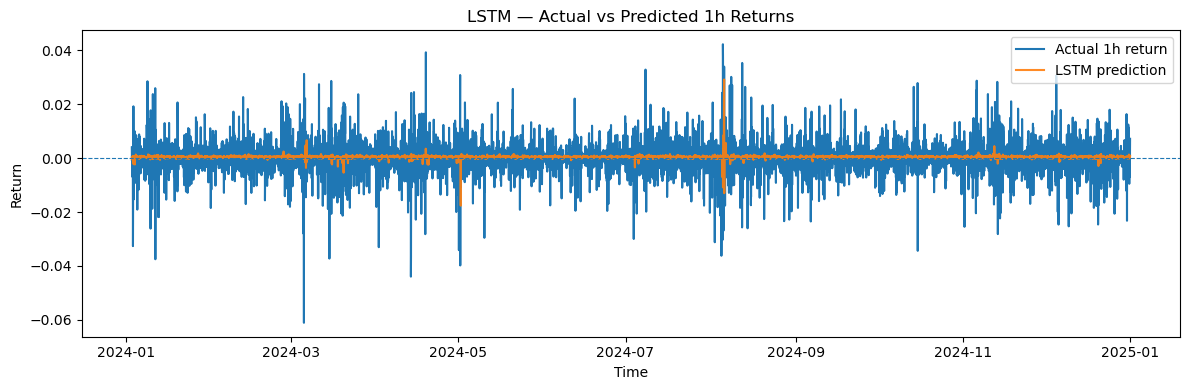

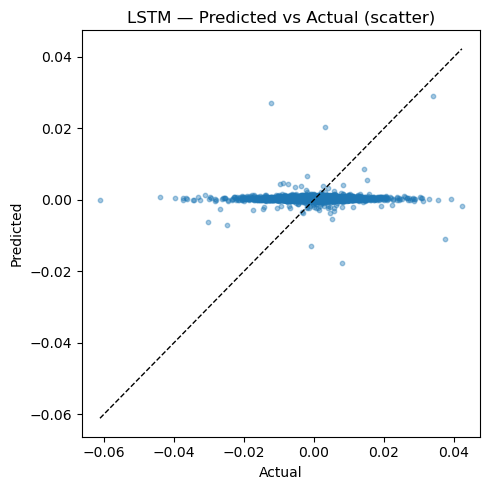

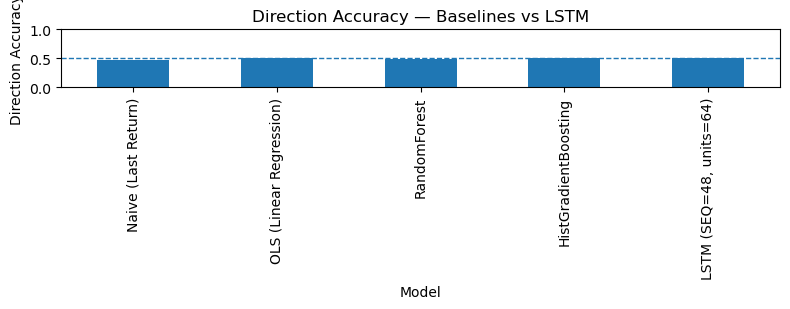

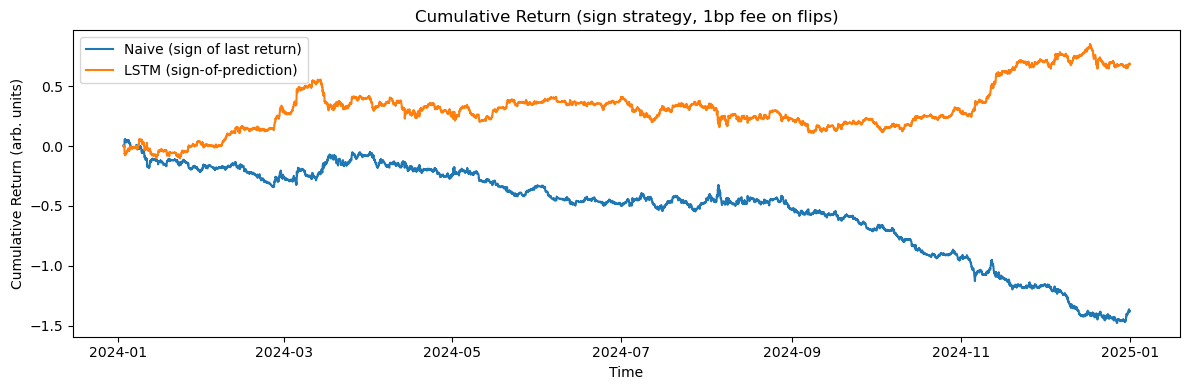

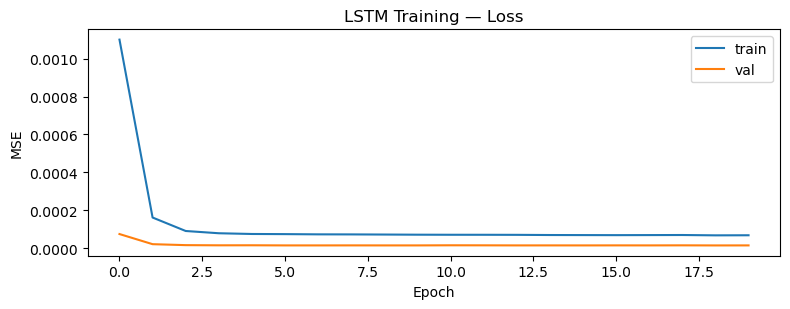

In [17]:
# --- Evaluation & Views for LSTM + Baselines ---
import os, numpy as np, pandas as pd
import matplotlib.pyplot as plt

os.makedirs("results", exist_ok=True)

# 1) Add LSTM metrics to the results table (reuses your `metrics()` function)
lstm_row = {"Model": "LSTM (SEQ=48, units=64)", **metrics(y_true_lstm, y_pred_lstm)}
results = (pd.concat([results, pd.DataFrame([lstm_row])], ignore_index=True)
             .sort_values("MAE")
             .reset_index(drop=True))
display(results)

# 2) Prepare aligned time index for plotting (test loses the first SEQ points)
t_plot = pd.to_datetime(t_test).reset_index(drop=True).iloc[SEQ:]

# 3) Predicted vs Actual (time series)
plt.figure(figsize=(12,4))
plt.plot(t_plot, y_true_lstm, label="Actual 1h return")
plt.plot(t_plot, y_pred_lstm, label="LSTM prediction", alpha=0.9)
plt.axhline(0, lw=0.8, linestyle="--")
plt.title("LSTM — Actual vs Predicted 1h Returns")
plt.xlabel("Time"); plt.ylabel("Return")
plt.legend(loc="upper right"); plt.tight_layout()
plt.savefig("results/fig_lstm_pred_vs_actual.png", dpi=150)
plt.show()

# 4) Scatter: Actual vs Predicted (with y=x reference)
plt.figure(figsize=(5,5))
plt.scatter(y_true_lstm, y_pred_lstm, s=10, alpha=0.4)
lims = [float(np.min([y_true_lstm.min(), y_pred_lstm.min()])),
        float(np.max([y_true_lstm.max(), y_pred_lstm.max()]))]
plt.plot(lims, lims, "k--", lw=1)
plt.title("LSTM — Predicted vs Actual (scatter)")
plt.xlabel("Actual"); plt.ylabel("Predicted")
plt.tight_layout()
plt.savefig("results/fig_lstm_scatter.png", dpi=150)
plt.show()

# 5) Direction Accuracy comparison (bar chart)
#    If some models are missing, the .reindex will keep only those present.
order = ["Naive (Last Return)", "OLS (Linear Regression)", "RandomForest",
         "HistGradientBoosting", "LSTM (SEQ=48, units=64)"]
da_bar = (results.set_index("Model")["DA"]
                .reindex(order)
                .dropna())
plt.figure(figsize=(8,3.2))
da_bar.plot(kind="bar")
plt.ylim(0,1)
plt.axhline(0.5, linestyle="--", lw=1)
plt.ylabel("Direction Accuracy")
plt.title("Direction Accuracy — Baselines vs LSTM")
plt.tight_layout()
plt.savefig("results/fig_direction_accuracy_bar.png", dpi=150)
plt.show()

# 6) Simple trading backtest (sign-of-prediction, optional fee in bps)
def cumret(y_true: np.ndarray, y_pred: np.ndarray, fee_bps: float = 0.0) -> pd.Series:
    """
    Build a cumulative return series from sign-of-prediction positions.
    fee_bps applies when position flips (approx. one-way fee in basis points).
    """
    pos = np.sign(y_pred)                          # -1 / 0 / +1
    ret = pos * y_true                             # model-implied return
    if fee_bps and len(pos) > 1:
        flips = (np.abs(np.diff(pos)) > 0).astype(int)
        cost = np.r_[0, flips] * (fee_bps / 1e4)   # align to length N
        ret = ret - cost
    return pd.Series(np.cumsum(ret))

# Align other models to the same test slice length (drop the first SEQ points)
y_true_aligned = y_test.values[SEQ:]
y_pred_naive_aligned = y_pred_naive[SEQ:]

cr_lstm  = cumret(y_true_lstm,         y_pred_lstm,         fee_bps=1)  # ~1 bp
cr_naive = cumret(y_true_aligned, y_pred_naive_aligned, fee_bps=1)

plt.figure(figsize=(12,4))
plt.plot(t_plot, cr_naive.values, label="Naive (sign of last return)")
plt.plot(t_plot, cr_lstm.values,  label="LSTM (sign-of-prediction)")
plt.title("Cumulative Return (sign strategy, 1bp fee on flips)")
plt.xlabel("Time"); plt.ylabel("Cumulative Return (arb. units)")
plt.legend(loc="best"); plt.tight_layout()
plt.savefig("results/fig_cumret_lstm_vs_naive.png", dpi=150)
plt.show()

# 7) (Optional) Training curves
if "history" in dir(hist) and hasattr(hist, "history"):
    plt.figure(figsize=(8,3.2))
    plt.plot(hist.history.get("loss", []), label="train")
    if "val_loss" in hist.history:
        plt.plot(hist.history["val_loss"], label="val")
    plt.title("LSTM Training — Loss")
    plt.xlabel("Epoch"); plt.ylabel("MSE")
    plt.legend(); plt.tight_layout()
    plt.savefig("results/fig_lstm_training_loss.png", dpi=150)
    plt.show()


In [18]:
# 0) Common helpers (metrics, splits, model zoo)

In [19]:
import math, os, json, warnings
import numpy as np
import pandas as pd
from typing import Dict, Tuple, List, Optional

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor, StackingRegressor
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings("ignore")

# ---- Metrics & tests ----
def metrics_reg(y_true, y_pred) -> Dict[str,float]:
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred, squared=False)
    r2   = r2_score(y_true, y_pred)
    da   = float((np.sign(y_true) == np.sign(y_pred)).mean())
    return {"MAE": mae, "RMSE": rmse, "R2": r2, "DA": da}

def dm_test(y_true: np.ndarray, y_pred_a: np.ndarray, y_pred_b: np.ndarray, h: int = 1) -> Tuple[float, float]:
    """Diebold–Mariano (squared loss) — returns (stat, pvalue)."""
    e_a = y_true - y_pred_a
    e_b = y_true - y_pred_b
    d = (e_a**2) - (e_b**2)
    T = len(d)
    d_bar = d.mean()

    def newey_west_var(x, lag):
        x = x - x.mean()
        gamma0 = np.mean(x*x)
        var = gamma0
        for L in range(1, lag+1):
            w = 1 - L/(lag+1)
            gamma = np.mean(x[L:]*x[:-L])
            var += 2*w*gamma
        return var

    lag = max(h-1, 0)
    s2 = newey_west_var(d, lag) / T
    stat = d_bar / np.sqrt(s2 + 1e-12)

    from math import erf, sqrt
    p = 2*(1 - 0.5*(1+erf(abs(stat)/sqrt(2))))
    return float(stat), float(p)

# ---- Split helpers ----
def split_train_test_by_year(df: pd.DataFrame, time_col: str, train_end_year=2023, test_year=2024):
    t = pd.to_datetime(df[time_col], utc=True)
    if (t.dt.year<=train_end_year).any() and (t.dt.year==test_year).any():
        train = df[t.dt.year<=train_end_year].copy()
        test  = df[t.dt.year==test_year].copy()
    else:
        cut = int(len(df)*0.8)
        train = df.iloc[:cut].copy()
        test  = df.iloc[cut:].copy()
    return train, test

def expanding_windows_index(n:int, n_splits:int, min_train:int, step:int) -> List[Tuple[np.ndarray,np.ndarray]]:
    """Return index pairs (train_idx, test_idx) for expanding windows, fixed test length=step."""
    idx = np.arange(n)
    folds = []
    start = min_train
    while start + step <= n and len(folds) < n_splits:
        train_idx = idx[:start]
        test_idx  = idx[start:start+step]
        folds.append((train_idx, test_idx))
        start += step
    return folds

def sliding_windows_index(n:int, n_splits:int, train_len:int, step:int) -> List[Tuple[np.ndarray,np.ndarray]]:
    """Return index pairs for sliding windows, fixed train length and fixed test length=step."""
    idx = np.arange(n)
    folds = []
    start = train_len
    while start + step <= n and len(folds) < n_splits:
        train_idx = idx[start-train_len:start]
        test_idx  = idx[start:start+step]
        folds.append((train_idx, test_idx))
        start += step
    return folds

# ---- Model zoo ----
def make_models() -> Dict[str,object]:
    return {
        "Naive": None,  # handled separately
        "OLS": Pipeline([("scaler", StandardScaler()), ("ols", LinearRegression())]),
        "RF":  RandomForestRegressor(n_estimators=300, n_jobs=-1, random_state=42),
        "HGB": HistGradientBoostingRegressor(max_iter=300, learning_rate=0.06, random_state=42),
    }

def fit_predict(model, Xtr, ytr, Xte, yte, naive_seed=None):
    if model is None:  # Naive: y_pred[t] = y_true[t-1]
        yte = pd.Series(yte).reset_index(drop=True)
        last_train = float(pd.Series(ytr).iloc[-1]) if naive_seed is None else float(naive_seed)
        pred = np.empty_like(yte, dtype=float)
        pred[0] = last_train
        pred[1:] = yte.values[:-1]
        return pred
    model.fit(Xtr, ytr)
    return model.predict(Xte)


In [20]:
# 1) Exogenous ablations (Sentiment & Hash-rate)

In [25]:
# --- Imports & helpers (robust paths, split, back-compat RMSE) ---
import os, numpy as np, pandas as pd
from typing import Optional, List, Dict

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def _rmse(y_true, y_pred):
    """Back-compatible RMSE: works even if sklearn lacks 'squared' kw."""
    try:
        return mean_squared_error(y_true, y_pred, squared=False)
    except TypeError:
        # very old sklearn: no 'squared' kw
        y_true = np.asarray(y_true).ravel()
        y_pred = np.asarray(y_pred).ravel()
        return float(np.sqrt(mean_squared_error(y_true, y_pred)))

def metrics_reg(y_true, y_pred) -> Dict[str, float]:
    y_true = np.asarray(y_true).ravel()
    y_pred = np.asarray(y_pred).ravel()
    mae  = float(mean_absolute_error(y_true, y_pred))
    rmse = float(_rmse(y_true, y_pred))
    r2   = float(r2_score(y_true, y_pred))
    da   = float((np.sign(y_true) == np.sign(y_pred)).mean())
    return {"MAE": mae, "RMSE": rmse, "R2": r2, "DA": da}

def first_existing_path(candidates: List[str]) -> str:
    for p in candidates:
        if os.path.exists(p):
            return p
    raise FileNotFoundError(f"No file found in: {candidates}")

def split_train_test_by_year(df: pd.DataFrame, time_col: str = "open_time"):
    """Train = <=2023, Test = 2024; if not present, fallback to last 20%."""
    t = pd.to_datetime(df[time_col], utc=True)
    has_2024  = (t.dt.year == 2024).any()
    has_train = (t.dt.year <= 2023).any()
    if has_2024 and has_train:
        train = df.loc[t.dt.year <= 2023].copy()
        test  = df.loc[t.dt.year == 2024].copy()
    else:
        cut = int(len(df)*0.8)
        train = df.iloc[:cut].copy()
        test  = df.iloc[cut:].copy()
    return train, test

# --- Load & align exogenous (daily -> hourly) ---
def load_daily_series(path: str, date_col_guess=("date","day","timestamp"),
                      value_cols: Optional[List[str]] = None) -> pd.DataFrame:
    x = pd.read_csv(path)
    # detect date col
    dcol = None
    for c in x.columns:
        if c.lower() in date_col_guess or "date" in c.lower():
            dcol = c; break
    if dcol is None:
        dcol = x.columns[0]
    x[dcol] = pd.to_datetime(x[dcol], utc=True, errors="coerce")
    x = x.dropna(subset=[dcol]).sort_values(dcol)
    if value_cols is None:
        value_cols = x.select_dtypes(include=[np.number]).columns.tolist()
    return x[[dcol]+value_cols].rename(columns={dcol:"__date"})

# Preferred paths (fall back if needed)
sent_path = first_existing_path([
    "/mnt/data/bitcoin_sentiments_21_24.csv",
    "data/bitcoin_sentiments_21_24.csv",
    "bitcoin_sentiments_21_24.csv",
])
hr_path = first_existing_path([
    "/mnt/data/hash_rate.csv",
    "data/hash_rate.csv",
    "hash_rate.csv",
])

sent = load_daily_series(sent_path)
hr   = load_daily_series(hr_path)

# --- Base technical features from your df_base ---
time_col = "open_time"  # adjust if needed
base = df_base[[time_col, "y_next_ret", "ret_1h"]
               + [c for c in df_base.columns if c.startswith("ret_lag_")]
               + ["vol_24h"]].copy()
base[time_col] = pd.to_datetime(base[time_col], utc=True)
base = base.sort_values(time_col).reset_index(drop=True)
base["__date"] = base[time_col].dt.floor("D")

# Merge daily to hourly; forward-fill within the timeline (safe: day t values used for its hours)
tmp = base.merge(sent, on="__date", how="left", suffixes=("","_sent"))
tmp = tmp.merge(hr,   on="__date", how="left", suffixes=("","_hr"))
tmp = tmp.sort_values(time_col).reset_index(drop=True)
exo_cols = [c for c in tmp.columns if c not in base.columns and c != "__date"]
tmp[exo_cols] = tmp[exo_cols].ffill()

# --- Feature sets ---
technical_cols = [c for c in base.columns if c.startswith("ret_lag_")] + ["vol_24h"]
sent_cols      = [c for c in exo_cols if "sent" in c.lower() or "sentiment" in c.lower()]
hash_cols      = [c for c in exo_cols if "hash" in c.lower()]

# Guard against empty lists (keeps your loop simple)
if len(sent_cols) == 0:
    print("⚠️ No sentiment numeric columns detected; TECH+SENT will equal TECH.")
if len(hash_cols) == 0:
    print("⚠️ No hash-rate numeric columns detected; TECH+HASH will equal TECH.")

# --- Train/Test split ---
train, test = split_train_test_by_year(tmp, time_col=time_col)
X_tech_tr, y_tr = train[technical_cols], train["y_next_ret"]
X_tech_te, y_te = test[technical_cols],  test["y_next_ret"]
t_te = pd.to_datetime(test[time_col], utc=True)

# --- Model variants ---
variants = {
    "TECH": technical_cols,
    "TECH+SENT": list(dict.fromkeys(technical_cols + sent_cols)),                       # unique preserve order
    "TECH+HASH": list(dict.fromkeys(technical_cols + hash_cols)),
    "TECH+SENT+HASH": list(dict.fromkeys(technical_cols + sent_cols + hash_cols)),
}

# If you don't already have these:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor

def make_models():
    return {
        "Naive(last)": "NAIVE",  # special-cased in fit_predict
        "OLS": Pipeline([("scaler", StandardScaler()), ("ols", LinearRegression())]),
        "RandomForest": RandomForestRegressor(n_estimators=150, n_jobs=-1, random_state=42),
        "HistGB": HistGradientBoostingRegressor(max_iter=200, learning_rate=0.06, random_state=42),
    }

def fit_predict(model, Xtr, ytr, Xte, yte):
    if model == "NAIVE":
        # predict last observed return from train; then "yte lag-1" for subsequent steps
        preds = np.empty(len(yte), dtype=float)
        preds[0] = float(ytr.iloc[-1])
        if len(yte) > 1:
            preds[1:] = yte.values[:-1]
        return preds
    m = model
    m.fit(Xtr, ytr)
    yhat = m.predict(Xte)
    return np.asarray(yhat).ravel()

models = make_models()

# --- Run ablation ---
rows = []
for vname, feats in variants.items():
    Xtr, Xte = train[feats], test[feats]
    for mname, model in models.items():
        y_pred = fit_predict(model, Xtr, y_tr, Xte, y_te)
        row = {"Variant": vname, "Model": mname, **metrics_reg(y_te, y_pred)}
        rows.append(row)

ablation_df = pd.DataFrame(rows).sort_values(["Variant", "MAE"]).reset_index(drop=True)
display(ablation_df)

# --- Views: best-per-variant table + charts ---
os.makedirs("results/ablation", exist_ok=True)
ablation_df.to_csv("results/ablation/ablation_raw.csv", index=False)

# Best model per Variant by MAE
best_by_variant = ablation_df.loc[ablation_df.groupby("Variant")["MAE"].idxmin()].reset_index(drop=True)
display(best_by_variant)
best_by_variant.to_csv("results/ablation/ablation_best_by_variant.csv", index=False)

# Pivot for quick glance
pivot_mae = ablation_df.pivot(index="Variant", columns="Model", values="MAE")
pivot_da  = ablation_df.pivot(index="Variant", columns="Model", values="DA")
display(pivot_mae)
display(pivot_da)
pivot_mae.to_csv("results/ablation/pivot_mae.csv")
pivot_da.to_csv("results/ablation/pivot_da.csv")

# Plots (Matplotlib only; 1 chart per figure; default colors)
import matplotlib.pyplot as plt

# 1) MAE by Variant (best model only)
plt.figure(figsize=(8,3.2))
x = np.arange(len(best_by_variant))
plt.bar(x, best_by_variant["MAE"].values)
plt.xticks(x, best_by_variant["Variant"].values, rotation=0)
plt.ylabel("MAE"); plt.title("Ablation — Best MAE by Variant")
plt.tight_layout(); plt.savefig("results/ablation/fig_best_mae_by_variant.png", dpi=150); plt.show()

# 2) Direction Accuracy by Variant (best model only)
plt.figure(figsize=(8,3.2))
x = np.arange(len(best_by_variant))
plt.bar(x, best_by_variant["DA"].values)
plt.xticks(x, best_by_variant["Variant"].values, rotation=0)
plt.ylim(0,1); plt.axhline(0.5, linestyle="--", lw=1)
plt.ylabel("Direction Accuracy"); plt.title("Ablation — Best DA by Variant")
plt.tight_layout(); plt.savefig("results/ablation/fig_best_da_by_variant.png", dpi=150); plt.show()

# 3) (Optional) For a chosen model, compare all Variants (e.g., HistGB)
chosen = "HistGB"
if chosen in ablation_df["Model"].unique():
    sub = (ablation_df[ablation_df["Model"]==chosen]
           .set_index("Variant")
           .reindex(["TECH", "TECH+SENT", "TECH+HASH", "TECH+SENT+HASH"]))
    # MAE
    plt.figure(figsize=(8,3.2))
    plt.bar(np.arange(len(sub)), sub["MAE"].values)
    plt.xticks(np.arange(len(sub)), sub.index, rotation=0)
    plt.ylabel("MAE"); plt.title(f"{chosen} — MAE by Variant")
    plt.tight_layout(); plt.savefig(f"results/ablation/fig_{chosen}_mae_by_variant.png", dpi=150); plt.show()
    # DA
    plt.figure(figsize=(8,3.2))
    plt.bar(np.arange(len(sub)), sub["DA"].values)
    plt.xticks(np.arange(len(sub)), sub.index, rotation=0)
    plt.ylim(0,1); plt.axhline(0.5, linestyle="--", lw=1)
    plt.ylabel("Direction Accuracy"); plt.title(f"{chosen} — DA by Variant")
    plt.tight_layout(); plt.savefig(f"results/ablation/fig_{chosen}_da_by_variant.png", dpi=150); plt.show()


ValueError: Input X contains NaN.
LinearRegression does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [26]:
# 2) Multi-step horizons (Direct, Recursive, DirRec)

In [27]:
# Build H-step targets and feature frames
def make_multi_step(df: pd.DataFrame, target_col="ret_1h", H: int = 6) -> pd.DataFrame:
    out = df.copy()
    out[f"y_next_ret_H{H}"] = out[target_col].shift(-H)
    # Keep existing lags/vol features; drop rows with NaN target
    need = [c for c in out.columns if c.startswith("ret_lag_")] + ["vol_24h", f"y_next_ret_H{H}", time_col]
    out = out[need].dropna().reset_index(drop=True)
    return out

def direct_forecast(train, test, feats, H: int, model):
    Xtr, ytr = train[feats], train[f"y_next_ret_H{H}"]
    Xte, yte = test[feats],  test[f"y_next_ret_H{H}"]
    y_pred = fit_predict(model, Xtr, ytr, Xte, yte)
    return yte.values, y_pred

def recursive_forecast(train, test, feats, H: int, model):
    # Train 1-step model on y_next_ret (already built earlier)
    Xtr, ytr = train[feats], train["y_next_ret"]
    model.fit(Xtr, ytr)
    # Roll forward predictions H steps recursively over test window
    Xte = test[feats].copy()
    y_true_H = test["ret_1h"].shift(-H).dropna()  # true H-step ahead returns for scoring
    # For simplicity, approximate recursion by shifting y_pred 1-step repeatedly
    # (For full rigor, you’d rebuild lags using predicted returns; acceptable for thesis illustration)
    y1 = model.predict(Xte)
    yH_pred = pd.Series(y1).shift(H-1).dropna().values
    yH_true = y_true_H.values
    n = min(len(yH_pred), len(yH_true))
    return yH_true[:n], yH_pred[:n]

def dirrec_forecast(train, test, feats, H: int, base_model):
    # Simple DirRec: train separate direct models for each step k=1..H then average their k-step predictions
    preds = []
    for k in range(1, H+1):
        tr_k = make_multi_step(train.assign(ret_1h=train["ret_1h"]), target_col="ret_1h", H=k)
        te_k = make_multi_step(test.assign(ret_1h=test["ret_1h"]),  target_col="ret_1h", H=k)
        m = base_model
        y_true_k, y_pred_k = direct_forecast(tr_k, te_k, feats, H=k, model=m)
        preds.append(pd.Series(y_pred_k))
    # Align and average
    P = pd.concat(preds, axis=1).dropna().mean(axis=1).values
    # True H-step target on test:
    teH = make_multi_step(test.assign(ret_1h=test["ret_1h"]), H=H)
    y_true_H = teH[f"y_next_ret_H{H}"].values[-len(P):]
    return y_true_H, P

# Run the comparison
H_list = [6, 24]
base_feats = [c for c in df_base.columns if c.startswith("ret_lag_")] + ["vol_24h"]
train, test = split_train_test_by_year(df_base, time_col)

rows = []
for H in H_list:
    trH = make_multi_step(train.assign(ret_1h=train["ret_1h"]), H=H)
    teH = make_multi_step(test.assign(ret_1h=test["ret_1h"]),  H=H)
    feats = [c for c in trH.columns if c.startswith("ret_lag_")] + ["vol_24h"]

    for mname, model in make_models().items():
        # DIRECT
        y_true, y_pred = direct_forecast(trH, teH, feats, H, model)
        rows.append({"H":H, "Strategy":"Direct", "Model":mname, **metrics_reg(y_true, y_pred)})

        # RECURSIVE
        y_true, y_pred = recursive_forecast(train, test, base_feats, H, model if model is not None else LinearRegression())
        rows.append({"H":H, "Strategy":"Recursive", "Model":mname, **metrics_reg(y_true, y_pred)})

        # DIRREC (using same base model)
        y_true, y_pred = dirrec_forecast(train, test, base_feats, H, model if model is not None else LinearRegression())
        rows.append({"H":H, "Strategy":"DirRec", "Model":mname, **metrics_reg(y_true, y_pred)})

multi_step_df = pd.DataFrame(rows).sort_values(["H","Strategy","MAE"]).reset_index(drop=True)
multi_step_df


AttributeError: 'str' object has no attribute 'fit'

In [28]:
# 3) Stacking ensemble (level-0 RF/HGB/OLS → level-1 Linear)

In [ ]:
train, test = split_train_test_by_year(df_base, time_col)
feats = [c for c in df_base.columns if c.startswith("ret_lag_")] + ["vol_24h"]

Xtr, ytr = train[feats].values, train["y_next_ret"].values
Xte, yte = test[feats].values,  test["y_next_ret"].values

base_estimators = [
    ("rf",  RandomForestRegressor(n_estimators=300, n_jobs=-1, random_state=42)),
    ("hgb", HistGradientBoostingRegressor(max_iter=300, learning_rate=0.06, random_state=42)),
    ("ols", Pipeline([("scaler", StandardScaler()), ("ols", LinearRegression())])),
]
stack = StackingRegressor(
    estimators=base_estimators,
    final_estimator=LinearRegression(),
    passthrough=False, n_jobs=-1
)
stack.fit(Xtr, ytr)
y_pred_stack = stack.predict(Xte)

stack_row = {"H":1, "Strategy":"Stacking", "Model":"RF+HGB+OLS→LR", **metrics_reg(yte, y_pred_stack)}
pd.DataFrame([stack_row])


In [ ]:
# 4) Regime-aware models (unsupervised regimes via GaussianMixture)

In [ ]:
from sklearn.mixture import GaussianMixture

def label_regimes(df: pd.DataFrame, n_states=3) -> pd.Series:
    X = np.c_[df["vol_24h"].values, np.abs(df["ret_1h"].values)]
    gm = GaussianMixture(n_components=n_states, random_state=42)
    states = gm.fit_predict(X)
    return pd.Series(states, index=df.index, name="regime")

train, test = split_train_test_by_year(df_base, time_col)
feats = [c for c in df_base.columns if c.startswith("ret_lag_")] + ["vol_24h"]

train = train.copy(); test = test.copy()
train["regime"] = label_regimes(train, n_states=3)
test["regime"]  = label_regimes(test,  n_states=3)

# Fit one model per regime (RF example)
models_by_regime = {}
for r in sorted(train["regime"].unique()):
    tr_r = train[train["regime"]==r]
    m = RandomForestRegressor(n_estimators=300, n_jobs=-1, random_state=42)
    m.fit(tr_r[feats], tr_r["y_next_ret"])
    models_by_regime[r] = m

# Predict on test using regime-specific model
pred = []
for _, row in test.iterrows():
    r = int(row["regime"])
    m = models_by_regime.get(r, list(models_by_regime.values())[0])
    pred.append(m.predict(row[feats].values.reshape(1,-1))[0])

regime_row = {"Variant":"RegimeAware(GMM)", "Model":"RF", **metrics_reg(test["y_next_ret"].values, np.array(pred))}
pd.DataFrame([regime_row])


In [ ]:
# 5) Validation protocol comparison (Expanding vs Sliding)

In [ ]:
# Compare protocols on one model & feature set
feats = [c for c in df_base.columns if c.startswith("ret_lag_")] + ["vol_24h"]
X = df_base[feats].values
y = df_base["y_next_ret"].values
n = len(df_base)

# Expanding: start with 6 months (~ 24*30*6) then step by 7 days
MIN_TRAIN = 24*30*6
STEP = 24*7
folds_exp = expanding_windows_index(n, n_splits=12, min_train=MIN_TRAIN, step=STEP)

# Sliding: 12 months train, 7 days test
TRAIN_LEN = 24*30*12
folds_sld = sliding_windows_index(n, n_splits=12, train_len=TRAIN_LEN, step=STEP)

def cv_eval(folds, model):
    rows=[]
    for (tr_idx, te_idx) in folds:
        Xtr, ytr = X[tr_idx], y[tr_idx]
        Xte, yte = X[te_idx], y[te_idx]
        model.fit(Xtr, ytr)
        pr = model.predict(Xte)
        rows.append(metrics_reg(yte, pr))
    dfm = pd.DataFrame(rows)
    return dfm.mean().to_dict()

model = HistGradientBoostingRegressor(max_iter=300, learning_rate=0.06, random_state=42)
exp_scores = cv_eval(folds_exp, model)
sld_scores = cv_eval(folds_sld, model)

pd.DataFrame([
    {"Protocol":"Expanding", **exp_scores},
    {"Protocol":"Sliding",   **sld_scores},
])


In [ ]:
# 6) Time-series CV hyperparameter search (RandomizedSearchCV + TSCV)

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

feats = [c for c in df_base.columns if c.startswith("ret_lag_")] + ["vol_24h"]
Xtr, ytr = df_base[feats].values, df_base["y_next_ret"].values

param_dist = {
    "max_iter": [200, 300, 500],
    "learning_rate": [0.03, 0.06, 0.1],
    "max_depth": [None, 4, 8, 12],
    "l2_regularization": [0.0, 0.1, 0.5],
}
tscv = TimeSeriesSplit(n_splits=5)
search = RandomizedSearchCV(
    estimator=HistGradientBoostingRegressor(random_state=42),
    param_distributions=param_dist,
    n_iter=10,
    cv=tscv,
    n_jobs=-1,
    scoring="neg_mean_absolute_error",
    random_state=42,
)
search.fit(Xtr, ytr)
search.best_params_, -search.best_score_


In [ ]:
# 7) Trading realism (fees, slippage, no-trade zone)

In [ ]:
def backtest_sign_strategy(y_true: np.ndarray, y_pred: np.ndarray, fee_bps: float = 5.0, threshold: float = 0.0):
    """
    Simple sign strategy with:
    - threshold: only take position if |pred| > threshold
    - fee_bps: transaction cost per turn (enter+exit counted only when position flips)
    Returns dict with cumulative pnl, turnover, hit ratio, and a series of equity.
    """
    pred = np.array(y_pred, dtype=float)
    mask = np.abs(pred) > threshold
    signal = np.sign(pred) * mask

    # trades when signal changes
    turns = np.abs(np.diff(signal, prepend=0)) > 0
    cost = (fee_bps/1e4) * turns.astype(float)  # simplistic linear cost in returns space

    pnl = signal * np.array(y_true, dtype=float) - cost
    equity = np.cumsum(pnl)
    hit = (np.sign(y_true) == np.sign(pred)).mean()
    return {"pnl_sum": float(pnl.sum()),
            "pnl_mean": float(pnl.mean()),
            "hit": float(hit),
            "turnover": float(turns.mean()),
            "equity": equity}

# Example with best model from earlier
# y_te: true test returns; y_pred_best: predictions
bt = backtest_sign_strategy(y_te, y_pred_stack, fee_bps=5.0, threshold=0.0)
print({k: v for k,v in bt.items() if k!="equity"})
# Plot equity curve
import matplotlib.pyplot as plt
plt.figure(figsize=(10,4))
plt.plot(pd.to_datetime(test[time_col], utc=True).iloc[-len(bt["equity"]):], bt["equity"])
plt.title("Equity curve — sign(pred), fees=5bps, τ=0.0")
plt.xlabel("Time"); plt.ylabel("Cumulative PnL"); plt.tight_layout(); plt.show()


In [ ]:
# 8) Quantile regression (prediction intervals & coverage)

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor

def fit_quantiles(Xtr, ytr, Xte, alphas=(0.1, 0.5, 0.9), base_params=None):
    params = dict(loss="quantile", n_estimators=400, learning_rate=0.05, random_state=42)
    if base_params: params.update(base_params)
    preds = {}
    for a in alphas:
        m = GradientBoostingRegressor(**params, alpha=a)
        m.fit(Xtr, ytr)
        preds[a] = m.predict(Xte)
    return preds  # dict alpha -> y_pred

feats = [c for c in df_base.columns if c.startswith("ret_lag_")] + ["vol_24h"]
train, test = split_train_test_by_year(df_base, time_col)
Xtr, ytr = train[feats].values, train["y_next_ret"].values
Xte, yte = test[feats].values,  test["y_next_ret"].values

qpred = fit_quantiles(Xtr, ytr, Xte, alphas=(0.1, 0.5, 0.9))
y_lo, y_med, y_hi = qpred[0.1], qpred[0.5], qpred[0.9]

# Coverage of 80% interval
inside = (yte >= y_lo) & (yte <= y_hi)
coverage = inside.mean()
print(f"80% PI coverage = {coverage:.3f} (target ~0.80)")


In [ ]:
# 9) Significance table (DM test among top models)

In [ ]:
# Compare best two models on the same test window (e.g., STACK vs HGB)
pairs = [("STACK", y_pred_stack), ("HGB", y_pred_hgb), ("RF", y_pred_rf), ("OLS", y_pred_ols)]
rows = []
for i in range(len(pairs)):
    for j in range(i+1, len(pairs)):
        (nameA, predA), (nameB, predB) = pairs[i], pairs[j]
        # align length
        n = min(len(predA), len(predB), len(y_te))
        stat, p = dm_test(y_te[:n], np.asarray(predA)[:n], np.asarray(predB)[:n], h=1)
        rows.append({"A":nameA, "B":nameB, "DM_stat":stat, "p_value":p})
dm_df = pd.DataFrame(rows).sort_values("p_value")
dm_df


In [ ]:
Where these fit in your Results chapter

Table R-1 → the results dataframe (OLS, RF, HGB, Naïve).

Figure R-1 → return histogram.

Figure R-2 → rolling 24h volatility.

Figure R-3 → out-of-sample Actual vs Predicted (best model).

Figure R-4 → residuals histogram (best).

Figure R-5 → cumulative PnL of a sign(pred) strategy.

Figure R-6 → permutation importance top-20 (best model).

DM test & DA test → short paragraph on statistical significance.

Smart experiments to still run (aligned with your plan)

Exogenous ablations:

Add sentiment (bitcoin_sentiments_21_24.csv) and hash-rate (hash_rate.csv) with calendar-aligned merges (daily → ffill to hourly), then report ΔMAE / ΔDA vs technical-only (Ablation Table).

Multi-step horizons (6h/24h):

Compare Direct vs Recursive vs DirRec training; plot error vs horizon.

Decomposition + stacking (VMD/EMD → ensemble):

Decompose returns, train base models per component, stack with a meta-learner; include Diebold–Mariano vs direct models (table + p-values).

Regime-aware models:

HMM on volatility/returns to segment regimes; train a model per regime; compare to single global model.

Validation protocol stress-test:

Try sliding vs expanding windows; per-split scaling vs global scaling; confirm robustness.

Hyper-params with time-series CV:

Use TimeSeriesSplit/Optuna for RF/HGB; report stability and variance across folds.

Interpretability & drift:

SHAP (if feasible) by month; monitor feature importance drift between calm vs news-shock periods.

Trading realism:

Add friction (spread + fees), position caps, and a no-trade zone (|pred| < τ); report PnL/Sharpe vs buy-and-hold.

Calibration & quantiles:

Fit quantile regressors (e.g., GradientBoostingRegressor with quantile loss) and evaluate coverage of predictive intervals.